# Analyze Visium HD data

This notebook walks through a typical Visium HD workflow in OmicVerse using both the **bin-level output** and the **cell segmentation output** from a 10x Genomics run. The example covers four tasks:

1. reading Visium HD data into `AnnData`,
2. visualizing gene expression on the tissue image,
3. identifying spatially variable genes in a local region and across the full section,
4. building a low-dimensional representation for clustering and spatial interpretation.

The code below assumes that the Visium HD output folders have already been downloaded and arranged under `data/visium_hd/`.


## Environment setup

We start by importing OmicVerse and enabling two notebook conveniences:

- `ov.style(font_path='Arial')` sets a consistent plotting style for the figures generated later in the notebook.
- `%load_ext autoreload` and `%autoreload 2` are optional, but useful during development because edited Python modules are reloaded automatically without restarting the kernel.


In [1]:
import omicverse as ov
ov.style(font_path='Arial')

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA A100-SXM4-40GB
      Memory: 39.4 GB | Compute: 8.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.10rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



`ov.settings.cpu_gpu_mixed_init()` initializes OmicVerse in mixed CPU/GPU mode. This is useful for workflows where some preprocessing steps remain CPU-bound while heavier numerical steps can benefit from GPU acceleration when available.


In [2]:
ov.settings.cpu_gpu_mixed_init()

CPU-GPU mixed mode activated
Available GPU accelerators: CUDA


## Load the Visium HD dataset

Visium HD provides expression measurements at very fine spatial resolution. In practice, two views of the same dataset are often useful:

- a **bin-level representation**, where counts are stored on a regular grid;
- a **cell-segmentation representation**, where bins are reassigned to segmented cells.

This notebook demonstrates both. The bin-level object is convenient for inspecting the raw spatial signal, while the segmentation-level object is more natural for downstream cell-centered analysis.


Before loading the matrices, it is often helpful to inspect the directory layout. The helper below prints the folder tree while skipping the `analysis` directory, which keeps the output focused on files needed for data import.

We download the count data and HE image from https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-human-prostate-cancer-ffpe.


In [7]:
from pathlib import Path

ov.utils.print_tree(
    Path("data/visium_hd/binned_outputs/square_016um"),
    skip_dirs={"analysis"}
)

square_016um/
    spatial/
        aligned_fiducials.jpg
        detected_tissue_image.jpg
        tissue_positions.parquet
        aligned_tissue_image.jpg
        tissue_lowres_image.png
        cytassist_image.tiff
        tissue_hires_image.png
        scalefactors_json.json
    raw_feature_bc_matrix.h5
    filtered_feature_bc_matrix/
        barcodes.tsv.gz
        features.tsv.gz
        matrix.mtx.gz
    filtered_feature_bc_matrix.h5
    raw_feature_bc_matrix/
        barcodes.tsv.gz
        features.tsv.gz
        matrix.mtx.gz


## Read the bin-level output

The first object is created from the `square_016um` directory, which stores Visium HD data binned on a regular grid.

A few parameters in `ov.io.read_visium_hd()` are worth noting:

- `path`: root folder of the selected Visium HD output.
- `data_type='bin'`: tells OmicVerse to interpret the input as a bin-level matrix rather than segmented cells.
- `cell_matrix_h5_path` and `count_mtx_dir`: point to the filtered count matrix in HDF5 and directory form.
- `tissue_positions_path`: provides spatial coordinates for each bin.
- `hires_image_path`, `lowres_image_path`, and `scalefactors_path`: link the molecular data to the tissue image for plotting.


In [8]:
adata_hd = ov.io.read_visium_hd(
    path="data/visium_hd/binned_outputs/square_016um",
    data_type="bin",
    cell_matrix_h5_path="filtered_feature_bc_matrix.h5",
    count_mtx_dir='filtered_feature_bc_matrix',
    tissue_positions_path = "spatial/tissue_positions.parquet",
    # if figure and scalefactor stored in  outs/spatial
    hires_image_path="spatial/tissue_hires_image.png",
    lowres_image_path="spatial/tissue_lowres_image.png",
    scalefactors_path="spatial/scalefactors_json.json",
)

[VisiumHD][INFO] read_visium_hd entry (data_type='bin')
[VisiumHD][START] Reading bin-level data from: /scratch/users/steorra/analysis/26_omic_protocol/data/visium_hd/binned_outputs/square_016um
[VisiumHD][INFO] Sample key: square_016um
[VisiumHD][STEP] Loading count matrix (h5='filtered_feature_bc_matrix.h5', mtx='filtered_feature_bc_matrix')
[VisiumHD][STEP] Loading tissue positions: /scratch/users/steorra/analysis/26_omic_protocol/data/visium_hd/binned_outputs/square_016um/spatial/tissue_positions.parquet
[VisiumHD][STEP] Loading images and scale factors
[VisiumHD][OK] Done (n_obs=139446, n_vars=18132)


The returned object is a standard `AnnData` container. At this stage it is useful to quickly inspect the number of observations, genes, and the contents of `obs`, `var`, `obsm`, and `uns`.


In [9]:
adata_hd

AnnData object with n_obs × n_vars = 139446 × 18132
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

The first plot overlays expression on the tissue image.

Key plotting arguments:

- `color=[None, "EPCAM"]`: show both the histology image alone and the expression of `EPCAM`.
- `size`: marker size for each spatial unit.
- `linewidth=0`: removes marker outlines for a cleaner dense plot.
- `cmap='Reds'`: uses a sequential colormap appropriate for nonnegative expression values.


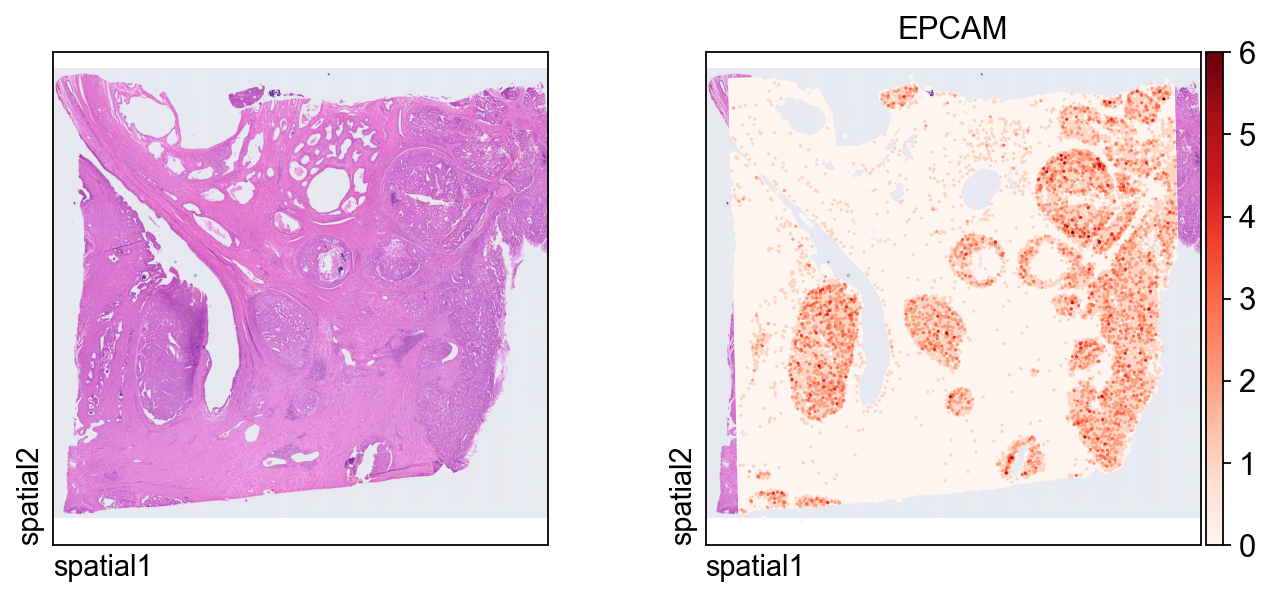

In [11]:
ov.pl.spatial(
    adata_hd, color=[None,"EPCAM"],
    size=3, linewidth=0,
    legend_fontsize=13, frameon=None,
    cmap='Reds'
)

## Read the cell-segmentation output

We now switch to the segmentation-level output, where observations correspond to segmented cells instead of regular bins. This representation is usually more appropriate for cell-level visualization, spatial feature discovery, and clustering.

Compared with the bin-level import, the main difference is the inclusion of a segmentation file:

- `data_type='cellseg'` activates the cell-segmentation parser.
- `cell_segmentations_path` points to the `geojson` file containing polygon boundaries for segmented cells.


In [3]:
adata_seg = ov.io.read_visium_hd(
    path="data/visium_hd/segmented_outputs",
    data_type="cellseg",
    cell_matrix_h5_path="filtered_feature_cell_matrix.h5",
    cell_segmentations_path="graphclust_annotated_cell_segmentations.geojson",
    # if figure and scalefactor stored in  outs/spatial
    hires_image_path="spatial/tissue_hires_image.png",
    lowres_image_path="spatial/tissue_lowres_image.png",
    scalefactors_path="spatial/scalefactors_json.json",
)

[VisiumHD][INFO] read_visium_hd entry (data_type='cellseg')
[VisiumHD][START] Reading cell-segmentation data from: /scratch/users/steorra/analysis/26_omic_protocol/data/visium_hd/segmented_outputs
[VisiumHD][INFO] Sample key: segmented_outputs
[VisiumHD][STEP] Loading segmentation geometry: /scratch/users/steorra/analysis/26_omic_protocol/data/visium_hd/segmented_outputs/graphclust_annotated_cell_segmentations.geojson
[VisiumHD][STEP] Loading count matrix: /scratch/users/steorra/analysis/26_omic_protocol/data/visium_hd/segmented_outputs/filtered_feature_cell_matrix.h5
[VisiumHD][STEP] Loading images and scale factors
[VisiumHD][OK] Done (n_obs=227257, n_vars=18132)


This plot shows the same marker, `EPCAM`, on the segmentation-level object. Because each observation now corresponds to a segmented cell, the spatial pattern is easier to interpret in a cell-centered way.


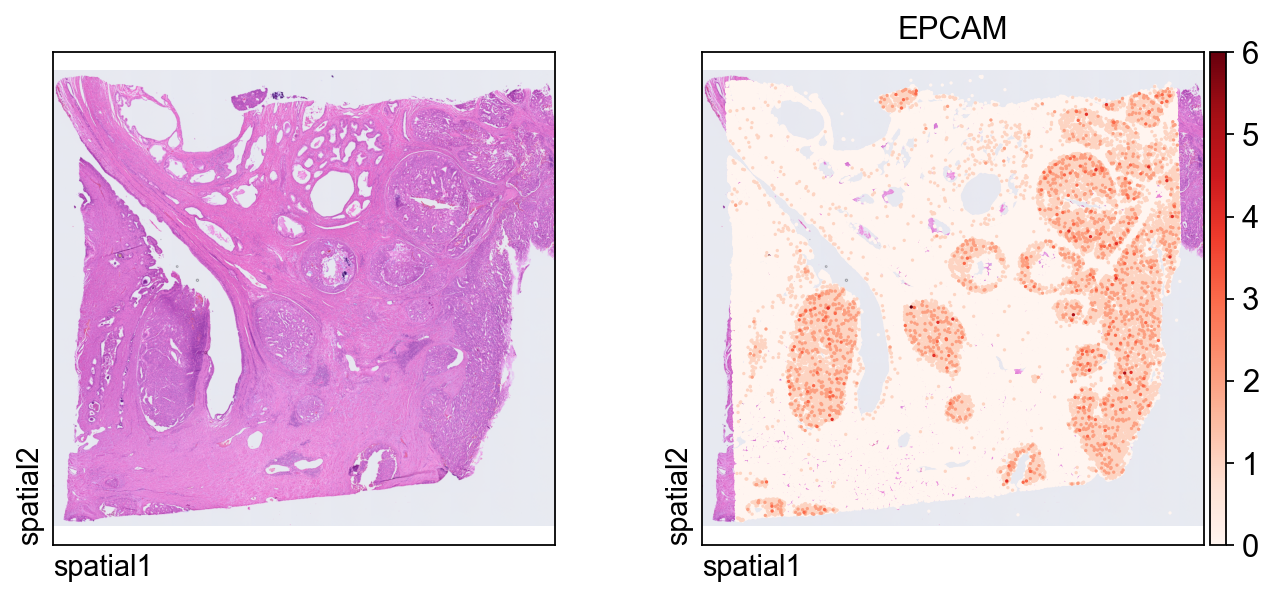

In [26]:
ov.pl.spatial(
    adata_seg, color=[None,"EPCAM"],
    size=6, linewidth=0,
    legend_fontsize=13, frameon=None,
    cmap='Reds'
)

## Focus on a local region of interest

Full-tissue plots are useful for context, but detailed inspection is often easier in a smaller window. The helper function below subsets the dataset by spatial coordinates.

Parameter notes:

- `xlim` and `ylim` define the rectangular region to keep.
- `adata.obsm["spatial"]` stores the x/y coordinates used for spatial filtering.
- `obs_names_make_unique()` and `var_names_make_unique()` guard against duplicated identifiers after subsetting.


In [3]:
def subset_data(adata, xlim=(24500, 26000), ylim=(5000, 6000)):
    x, y = adata.obsm["spatial"].T
    bdata = adata[(xlim[0] <= x) & (x <= xlim[1]) & (ylim[0] <= y) & (y <= ylim[1])].copy()
    bdata.obs_names_make_unique()
    bdata.var_names_make_unique()
    return bdata
bdata = subset_data(adata_seg)

The next few panels compare different ways of rendering the same segmented region. This is mainly a visualization step, but it is useful for deciding how much of the segmentation boundary should be shown in final figures.


Here the segmentation polygons are rendered without visible borders (`edges_width=0`). This emphasizes the expression signal itself and is often a good default when the field is crowded.


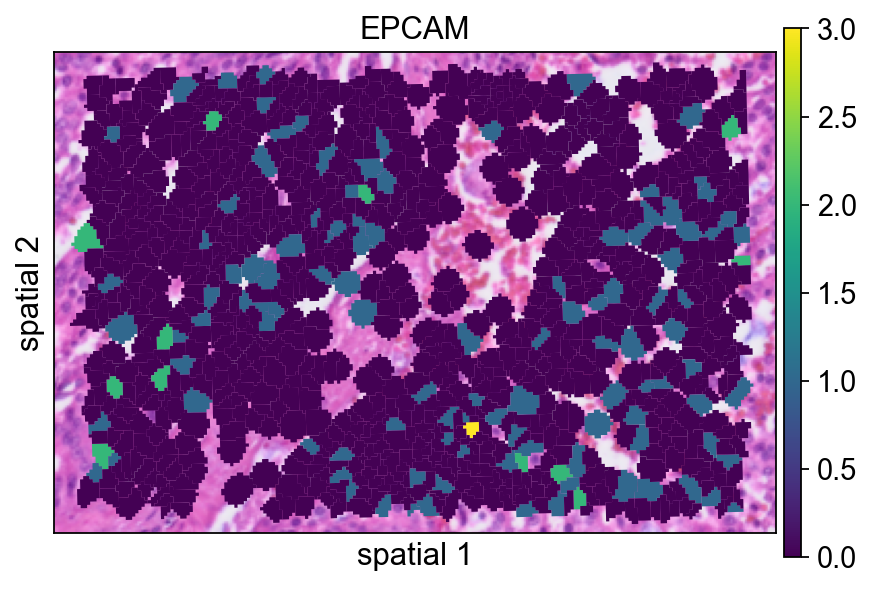

<Axes: title={'center': 'EPCAM'}, xlabel='spatial 1', ylabel='spatial 2'>

In [21]:
ov.pl.spatialseg(
    bdata,
    color="EPCAM",
    edges_color='white',
    edges_width=0,
    figsize=(6, 4),
    alpha_img=1,
    alpha=1,
    legend_fontsize=13,
    #cmap='Reds',
    #img_key=False,
    #alpha=1,
)

Adding a small border (`edges_width=0.1`) helps separate neighboring cells. This usually improves readability when adjacent segments have similar expression values.


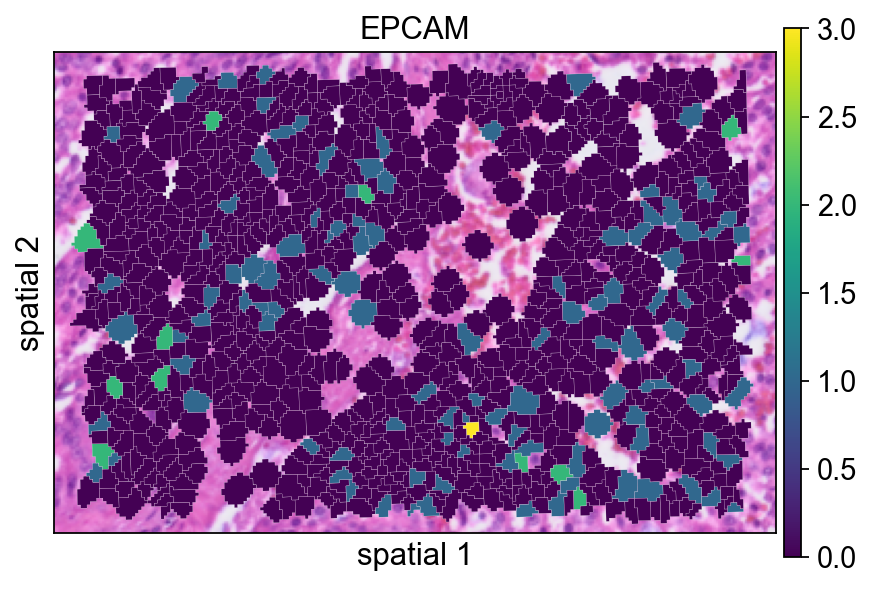

<Axes: title={'center': 'EPCAM'}, xlabel='spatial 1', ylabel='spatial 2'>

In [22]:
ov.pl.spatialseg(
    bdata,
    color="EPCAM",
    edges_color='white',
    edges_width=0.1,
    figsize=(6, 4),
    alpha_img=1,
    alpha=1,
    legend_fontsize=13,
    #cmap='Reds',
    #img_key=False,
)

`seg_contourpx` controls the thickness of the segmentation contour in pixel units. Increasing this value can make boundaries easier to see, especially in presentation figures or when the background image is visually busy.


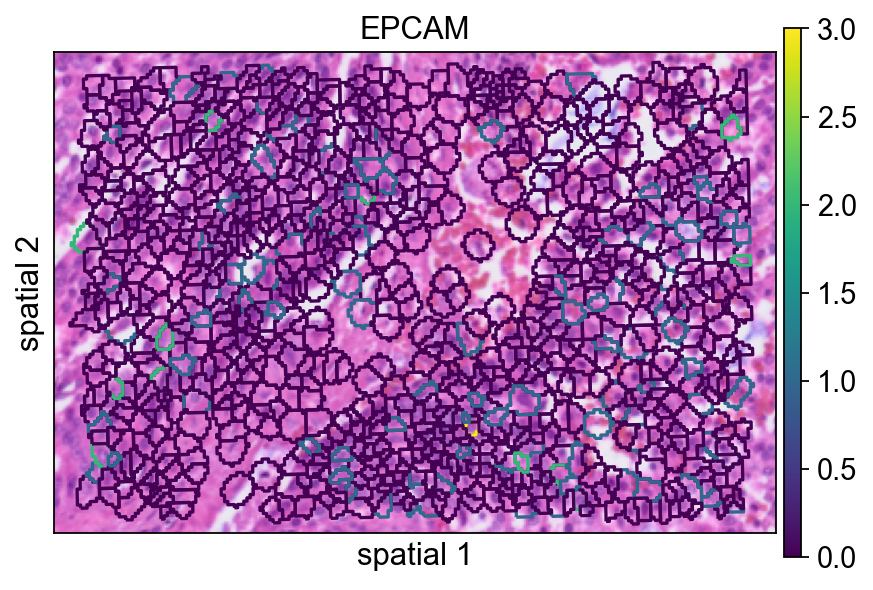

<Axes: title={'center': 'EPCAM'}, xlabel='spatial 1', ylabel='spatial 2'>

In [24]:
ov.pl.spatialseg(
    bdata,
    color="EPCAM",
    edges_color='white',
    edges_width=0,
    figsize=(6, 4),
    #library_id='1',
    alpha_img=1,
    seg_contourpx=1.5,
    alpha=1,
    legend_fontsize=13,
)

## Identify spatially variable genes in the local region

We next run `ov.space.svg()` on the subsetted region.

Important parameters:

- `mode='moranI'`: ranks genes by spatial autocorrelation using Moran's *I*.
- `n_svgs=3000`: keeps the top 3,000 candidate spatially variable genes.
- `n_perms=100`: uses permutations to estimate statistical significance.
- `n_jobs=8`: parallelizes the computation across CPU workers.


In [4]:
bdata=ov.space.svg(
    bdata,mode='moranI',
    n_svgs=3000,
    n_perms=100,n_jobs=8,
)
bdata

Spatial neighbors: 961 cells, 5582 connections (avg 5.8 neighbors/cell).
Stored in adata.obsp['spatial_connectivities'] and adata.obsp['spatial_distances'].
Stored 18132 gene results in adata.uns['moranI'].


AnnData object with n_obs × n_vars = 961 × 18132
    obs: 'geometry'
    var: 'gene_ids', 'feature_types', 'genome', 'moranI', 'moranI_pval', 'pval_adj', 'space_variable_features', 'highly_variable'
    uns: 'spatial', 'omicverse_io', 'spatial_neighbors', 'REFERENCE_MANU', 'moranI'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

The table below is a quick way to inspect the top-ranked genes. `moranI` measures the strength of spatial autocorrelation, `moranI_pval` records the significance estimate, and `space_variable_features` marks genes retained as spatial features.


In [7]:
bdata.var[['moranI','moranI_pval','space_variable_features']].sort_values('moranI',ascending=False)

,moranI,moranI_pval,space_variable_features
CHGA,0.422765,9.294550e-111,True
NPY,0.412106,2.276425e-105,True
PLA2G2A,0.387953,1.158365e-93,True
COL1A1,0.343667,5.067257e-74,True
KLK3,0.341580,3.733330e-73,True
...,...,...,...
SNU13,-0.033147,9.546428e-01,False
TRIOBP,-0.034662,9.617609e-01,False
SETD5,-0.036784,9.701712e-01,False
HNRNPL,-0.041451,9.833822e-01,False


`NPY` is plotted here as an example of a gene with localized spatial structure. Using a segmented rendering makes it easier to see whether the signal follows coherent cell neighborhoods rather than isolated spots.


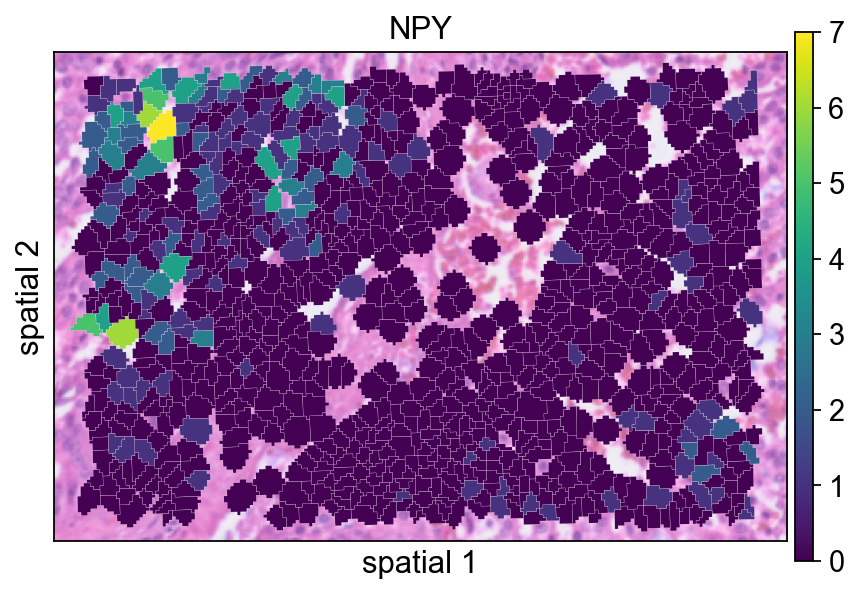

<Axes: title={'center': 'NPY'}, xlabel='spatial 1', ylabel='spatial 2'>

In [9]:
ov.pl.spatialseg(
    bdata,
    color="NPY",
    edges_color='white',
    edges_width=0.1,
    figsize=(6, 4),
    alpha_img=0.8,
    alpha=1,
    legend_fontsize=13,
)

Checking the maximum value in `X` before normalization is a simple sanity check. It gives a rough sense of the raw count scale in the subsetted object.


In [10]:
bdata.X.max()

21.0

## Normalize and log-transform the local subset

The standard preprocessing step here is:

- `ov.pp.normalize_total(bdata)`: normalize each observation to a comparable library size;
- `ov.pp.log1p(bdata)`: apply a log(1+x) transform to compress the dynamic range.

This usually makes spatial expression maps easier to compare across cells.


In [11]:
ov.pp.normalize_total(bdata)
ov.pp.log1p(bdata)


🔍 Count Normalization:
   Target sum: median
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 961 cells × 18,132 genes
   ✓ Runtime: 0.00s


After normalization and log transformation, the value range should be much smaller than in the raw matrix. This confirms that the transformation has been applied.


In [12]:
bdata.X.max()

4.4248466

Replotting `NPY` after preprocessing helps assess how normalization changes the visual contrast of the signal.


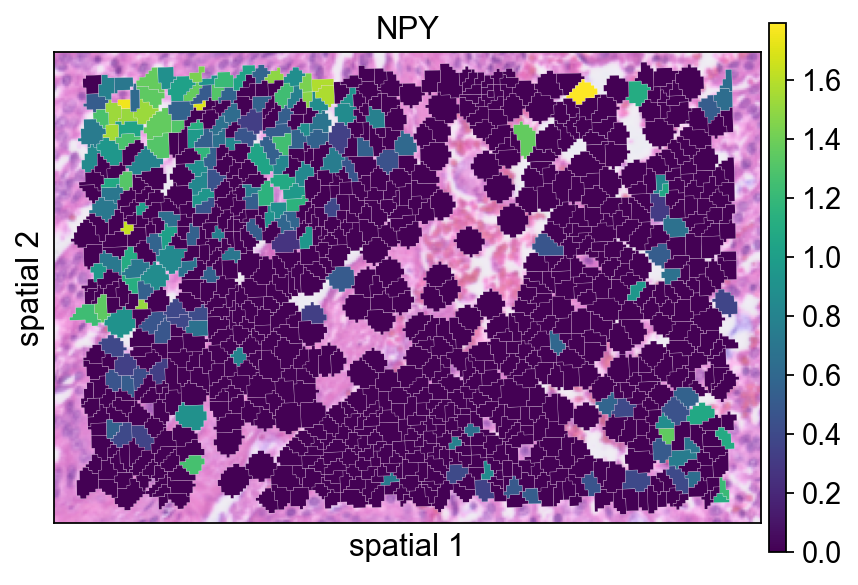

<Axes: title={'center': 'NPY'}, xlabel='spatial 1', ylabel='spatial 2'>

In [13]:
ov.pl.spatialseg(
    bdata,
    color="NPY",
    edges_color='white',
    edges_width=0.1,
    figsize=(6, 4),
    alpha_img=0.8,
    alpha=1,
    legend_fontsize=13,
)

The same gene is also shown with `ov.pl.spatial()`, which renders observations as points instead of filled segmentation polygons.

Two arguments are especially useful here:

- `size=1.5`: controls the point size for each observation;
- `vmax='p99.2'`: clips the color scale at the 99.2nd percentile, reducing the influence of extreme outliers on the visual dynamic range.


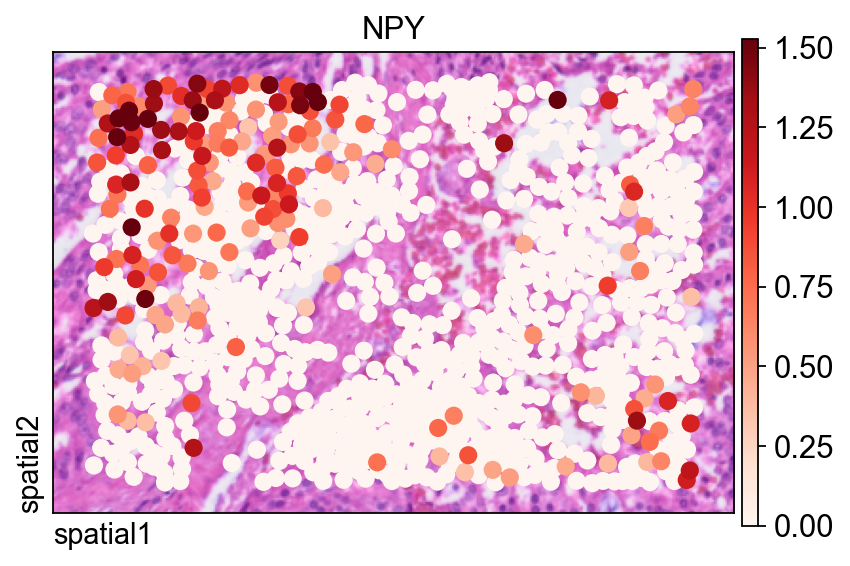

In [20]:
fig, ax = ov.plt.subplots(figsize=(6, 4))
ov.pl.spatial(
    bdata, color="NPY",
    size=1.5, linewidth=0,
    legend_fontsize=13, frameon=True,
    cmap='Reds',vmax='p99.2',
    ax=ax,
)

## Compute spatially variable genes on the full segmentation-level dataset

After exploring one local region, we repeat SVG detection on the full segmentation object. Here the notebook uses `mode='pearsonr'`, which applies a different criterion than Moran's *I* for detecting spatial structure.


In [4]:
adata=ov.space.svg(
    adata_seg,mode='pearsonr',
    n_svgs=3000,
)
adata

🔍 [2026-03-08 04:48:27] Running preprocessing in 'cpu-gpu-mixed' mode...
Begin robust gene identification
    After filtration, 18109/18132 genes are kept.
    Among 18109 genes, 13307 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1,410 highly-expressed genes from normalization computation
   ⚠️ Warning: 620 cells have zero counts

✅ Count Normalization Completed Successfully!
   ✓ Processed: 227,257 cells × 13,307 genes
   ✓ Runtime: 7.77s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 13,307 total (22.5%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (

AnnData object with n_obs × n_vars = 227257 × 18132
    obs: 'geometry'
    var: 'gene_ids', 'feature_types', 'genome', 'space_variable_features', 'highly_variable'
    uns: 'spatial', 'omicverse_io', 'REFERENCE_MANU'
    obsm: 'spatial'

Again, it is useful to check the value range before preprocessing the full dataset.


In [5]:
adata.X.max()

332.0

The full dataset is normalized and log-transformed in the same way as the local subset so that downstream dimensionality reduction and clustering operate on a comparable scale.


In [6]:
ov.pp.normalize_total(adata)
ov.pp.log1p(adata)


🔍 Count Normalization:
   Target sum: median
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 227,257 cells × 18,132 genes
   ✓ Runtime: 0.10s


## Restrict the matrix to spatially variable genes

Storing `adata.raw = adata` preserves the full prefiltered object for later reference. The next line subsets the matrix to genes marked in `adata.var.space_variable_features`, which reduces noise and focuses downstream analysis on spatially informative features.


In [7]:
%%time
adata.raw = adata
adata = adata[:, adata.var.space_variable_features]
adata

CPU times: user 13 ms, sys: 70.1 ms, total: 83.1 ms
Wall time: 82.1 ms


View of AnnData object with n_obs × n_vars = 227257 × 3000
    obs: 'geometry'
    var: 'gene_ids', 'feature_types', 'genome', 'space_variable_features', 'highly_variable'
    uns: 'spatial', 'omicverse_io', 'REFERENCE_MANU', 'log1p'
    obsm: 'spatial'

## Build a neighborhood graph and UMAP embedding

This cell follows the standard sequence of scaling, PCA, graph construction, and UMAP embedding.

Parameter notes:

- `n_pcs=50` in PCA keeps the first 50 principal components.
- `n_neighbors=15` defines the size of the local neighborhood used to build the graph.
- `use_rep='scaled|original|X_pca'` specifies which processed representation `ov.pp.neighbors()` should use under the OmicVerse convention employed in this workflow. In practice, this cell relies on the PCA representation generated immediately above.


In [8]:
%%time
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='scaled|original|X_pca')
ov.pp.umap(adata)


    Converting scaled data to csr_matrix format...

╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 29.9081s                                                │
│  Shape:    227,257 x 3,000 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ status                                               │
│           │ ✚ status_args                                          │
│                                                                    │
│  ● LAYERS │ ✚ scaled (sparse matrix, 227257x3000)                  │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA A100-SXM4-40GB
    

Training:   5%|▌         | 1/20 [00:07<02:27]

✓ New best loss: 0.2845


Training:  10%|█         | 2/20 [00:12<01:45]

✓ New best loss: 0.2564


...

L1 Batched(476):   0%|          | 0/100 [00:00<?, ?it/s]

L2 Batched(476):   0%|          | 0/100 [00:00<?, ?it/s]

L3 Batched(476):   0%|          | 0/100 [00:00<?, ?it/s]

L4 Batched(476):   0%|          | 0/100 [00:00<?, ?it/s]

done: 54 clusters (0:04:36)

╭─ SUMMARY: leiden ──────────────────────────────────────────────────╮
│  Duration: 276.2389s                                               │
│  Shape:    227,257 x 3,000 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ leiden (category)                                    │
│                                                                    │
│  ● UNS    │ ✚ leiden                                               │
│           │ └─ params: {'resolution': 1.0, 'random_state': 0, 'local_i...│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
CPU times: user 1h 49min 38s, sys: 27min 27s, total: 2h 17min 5s
Wall time: 45min 29s


Leiden clustering partitions the graph into communities. The `resolution` parameter controls cluster granularity: lower values produce fewer, broader groups, while higher values split the graph more aggressively.


In [13]:
ov.pp.leiden(adata,resolution=0.3)

⚙️ Using torch CPU/GPU mixed mode to calculate Leiden...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA A100-SXM4-40GB
    ------------------------------ 575/40960 MiB (1.4%)
Using batch size `n_batches` calculated from sqrt(n_obs): 476
Running GPU Leiden (batched)
Device: cpu


Leiden:   0%|          | 0/10 [00:00<?, ?it/s]

L0 Batched(476):   0%|          | 0/100 [00:00<?, ?it/s]

L1 Batched(476):   0%|          | 0/100 [00:00<?, ?it/s]

L2 Batched(476):   0%|          | 0/100 [00:00<?, ?it/s]

L3 Batched(476):   0%|          | 0/100 [00:00<?, ?it/s]

done: 13 clusters (0:05:32)

╭─ SUMMARY: leiden ──────────────────────────────────────────────────╮
│  Duration: 332.9071s                                               │
│  Shape:    227,257 x 3,000 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


Plotting `leiden` directly in tissue space is a quick way to judge whether transcriptional clusters align with coherent anatomical or histological domains.


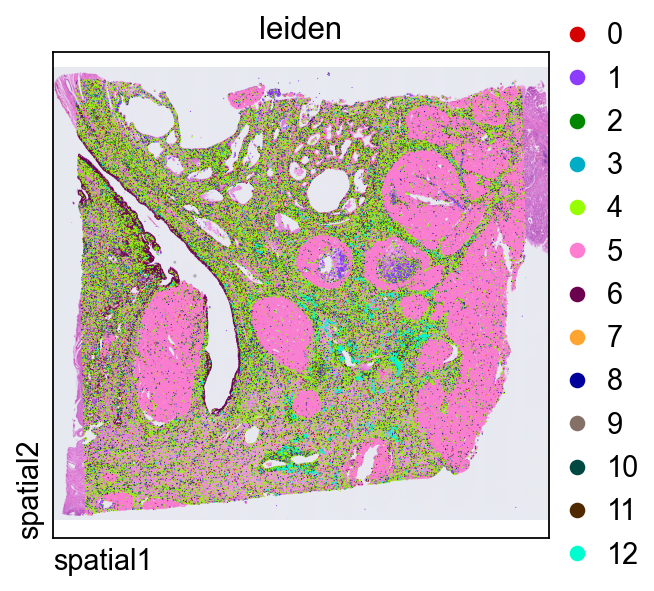

In [16]:
ov.pl.spatial(
    adata, color=["leiden"],
    size=2, linewidth=0,
    legend_fontsize=13, frameon=None,
    cmap='Reds'
)

## Zoom in on clusters within the same local region

Finally, we subset the clustered object to the same spatial window used earlier. This makes it easier to compare cluster assignments with the original marker expression and segmentation boundaries.


In [17]:
def subset_data(adata, xlim=(24500, 26000), ylim=(5000, 6000)):
    x, y = adata.obsm["spatial"].T
    bdata = adata[(xlim[0] <= x) & (x <= xlim[1]) & (ylim[0] <= y) & (y <= ylim[1])].copy()
    bdata.obs_names_make_unique()
    bdata.var_names_make_unique()
    return bdata
cdata = subset_data(adata)

This view overlays cluster labels on segmentation polygons with partial transparency. It is useful for checking whether cluster transitions follow visible tissue structures.


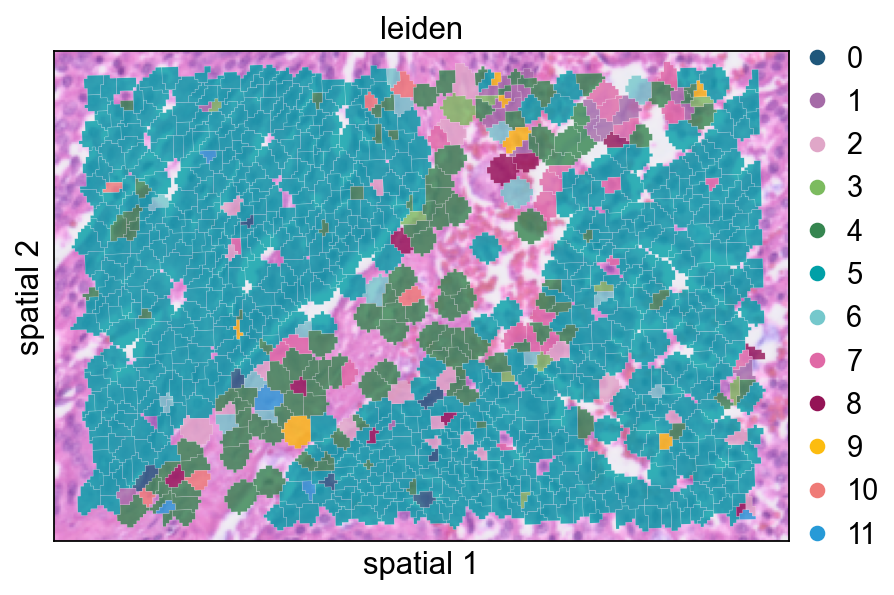

<Axes: title={'center': 'leiden'}, xlabel='spatial 1', ylabel='spatial 2'>

In [24]:
ov.pl.spatialseg(
    cdata,
    color="leiden",
    edges_color='white',
    edges_width=0.1,
    figsize=(6, 4),
    alpha_img=0.8,
    alpha=0.8,
    legend_fontsize=13,
    palette=ov.pl.sc_color
)

Increasing `seg_contourpx` sharpens the polygon outlines, which can make fine boundaries between neighboring clusters easier to inspect.


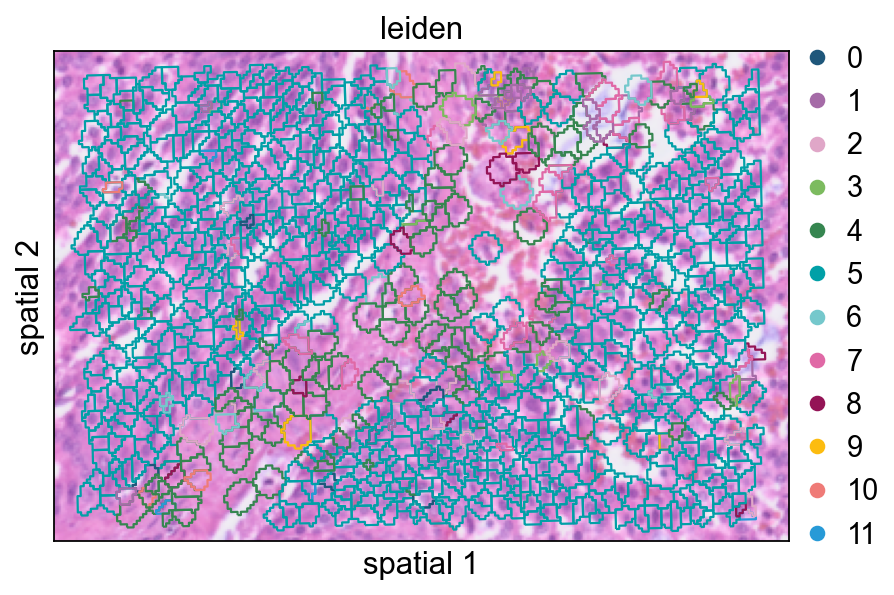

<Axes: title={'center': 'leiden'}, xlabel='spatial 1', ylabel='spatial 2'>

In [22]:
ov.pl.spatialseg(
    cdata,
    color="leiden",
    edges_color='white',
    edges_width=0.1,
    figsize=(6, 4),
    alpha_img=0.8,
    alpha=1,
    legend_fontsize=13,
    palette=ov.pl.sc_color,
    seg_contourpx=1,
)

## Summary

In this notebook, we:

- imported Visium HD data at both bin level and segmentation level,
- compared spatial visualization styles,
- identified spatially variable genes locally and globally,
- normalized the data and restricted the analysis to spatial features,
- constructed a low-dimensional embedding and clustered the segmented cells.

This combination of image-aware visualization and expression-based clustering provides a practical starting point for Visium HD analysis in OmicVerse.
